In [1]:
import math
# Calculate values for sign test
for i in range(20):
    n = i*5
    print(n, end= ':   ')
    print(math.ceil(n/2+0.98*math.sqrt(n)), end = ', ')
    print(n/2+0.98*math.sqrt(n))

0:   0, 0.0
5:   5, 4.691346617949794
10:   9, 8.099032106965012
15:   12, 11.295523679283269
20:   15, 14.382693235899588
25:   18, 17.4
30:   21, 20.367681063550627
35:   24, 23.297758187437623
40:   27, 26.198064213930024
45:   30, 29.07403985384938
50:   32, 31.929646455628166
55:   35, 34.76787451735375
60:   38, 37.591047358566534
65:   41, 40.40101259333258
70:   44, 43.19926826003394
75:   46, 45.987048957087495
80:   49, 48.765386471799175
85:   52, 51.53515356814703
90:   55, 54.29709632089504
95:   58, 57.051858457912786


In [2]:
for n in [81, 27]:
    print(n/2+0.98*math.sqrt(n))

49.32
18.592229374252497


In [3]:
import pandas as pd
df = pd.read_csv('FirstExperimentWith_w.csv')
l = []
for w,i in zip(df['w'], df['index']):
    if i == 9999:
        l.append(w)
    else:
        l.append(i)
df['value']=l
df.drop('index', axis=1, inplace=True)

In [4]:
df.drop(axis=1, labels=["errormargin", "pollutionplus", "exceptionalplus"]).groupby(by=["w", "typebeam"]).mean()

value
w  typebeam           
10 Jaccard    6.592593
   Old       10.000000
   normal     6.481481
25 Jaccard   12.481481
   Old       25.000000
   normal    13.000000
60 Jaccard   23.814815
   Old       60.000000
   normal    27.777778

In [5]:
df.drop(axis=1, labels=["w", "pollutionplus", "exceptionalplus"]).groupby(by=["errormargin", "typebeam"]).mean()

value
errormargin typebeam           
0.5         Jaccard   12.481481
            Old       31.666667
            normal    13.074074
2.0         Jaccard   14.259259
            Old       31.666667
            normal    17.259259
10.0        Jaccard   16.148148
            Old       31.666667
            normal    16.925926

In [6]:
df.drop(axis=1, labels=["w", "errormargin"]).groupby(by=["pollutionplus", "exceptionalplus", "typebeam"]).mean()

value
pollutionplus exceptionalplus typebeam           
4             1               Jaccard    8.777778
                              Old       31.666667
                              normal    10.777778
              3               Jaccard    4.222222
                              Old       31.666667
                              normal     5.222222
              5               Jaccard    4.111111
                              Old       31.666667
                              normal     5.000000
8             1               Jaccard   28.777778
                              Old       31.666667
                              normal    31.333333
              3               Jaccard   11.777778
                              Old       31.666667
                              normal    13.444444
              5               Jaccard    4.333333
                              Old       31.666667
                              normal     5.555556
20            1               Jaccard   30.555556
                              Old       31.666667
                              normal    30.666667
              3               Jaccard   19.888889
                              Old       31.666667
                              normal    22.777778
              5               Jaccard   16.222222
                              Old       31.666667
                              normal    17.000000

In [7]:
Jaccardvalues = df[(df['typebeam']== 'Jaccard')&(df['w']==25)]['value']
normalvalues = df[(df['typebeam']== 'normal')&(df['w']==25)]['value'] 
resultlist = []
for i, j in zip(normalvalues, Jaccardvalues):
    if i == j:
        resultlist.append('Tie')
    elif i>j:
        resultlist.append('Win')
    else:
        resultlist.append('Loss')
print(resultlist.count('Win'))
print(resultlist.count('Tie'))
print(resultlist.count('Loss'))

11
12
4


In [8]:
df.columns

Index(['w', 'errormargin', 'pollutionplus', 'exceptionalplus', 'typebeam',
       'value'],
      dtype='object')

In [9]:
df = pd.read_csv('SecondExcperiment.csv')
a,b,c,d,e,f = [], [], [], [], [], []
for w,i,j,k,l,n,m in zip(df['w'], df['pollution1'], df['pollution2'], df['exceptional1'], df['exceptional2'], df['exceptionalexclude'], df['exceptionaloverlap']):
    for lst, value in zip([a,b,c,d,e,f], [i,j,k,l,n,m]):
        if int(value) == 9999:
            lst.append(w)
        else:
            lst.append(value)
df.drop(['pollution1', 'pollution2', 'exceptional1', 'exceptional2', 'exceptionalexclude', 'exceptionaloverlap'], axis=1, inplace=True)
df['pollution1'] = a
df['pollution2'] = b
df['exceptional1'] = c
df['exceptional2'] = d
df['exceptionalexclude'] = e
df['exceptionaloverlap'] = f

In [22]:
df['superdiff']= abs(df['pollutionplus']-df['superexceptionalplus'])
dfg = df.drop(axis=1, labels=["errormargin","superexceptionalplus", "pollutionplus", "exceptionalplus", "exceptional1", "exceptional2", "w"]).groupby(by=["superdiff", "typebeam"]).mean()
dfg.reset_index(inplace=True)
dfg

,superdiff,typebeam,pollution1,pollution2,exceptionalexclude,exceptionaloverlap
0,0,Jaccard,4.740741,1.888889,12.629630,31.666667
1,0,normal,5.740741,1.888889,17.037037,31.666667
2,4,Jaccard,3.981481,1.555556,18.074074,31.666667
3,4,normal,5.037037,1.555556,18.574074,31.666667
4,5,Jaccard,3.111111,25.259259,6.000000,31.370370
5,5,normal,3.555556,25.259259,7.407407,31.666667
6,8,Jaccard,11.092593,4.000000,12.907407,31.055556
7,8,normal,14.240741,4.425926,16.425926,31.166667
8,16,Jaccard,2.851852,2.370370,25.333333,31.370370
9,16,normal,2.888889,2.370370,27.111111,31.185185


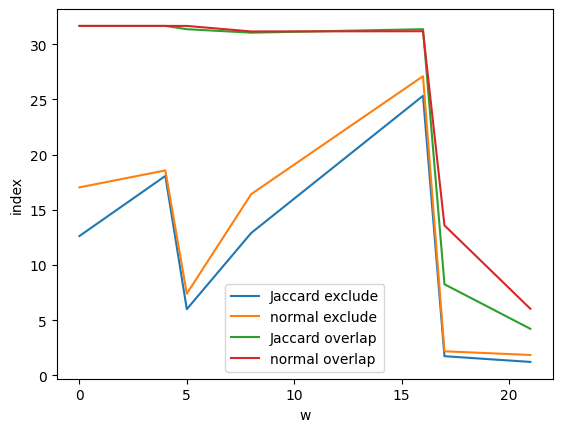

In [27]:
import matplotlib.pyplot as plt
x = dfg[dfg['typebeam']== 'Jaccard']['superdiff']
y = dfg[dfg['typebeam']== 'Jaccard']['exceptionalexclude']
plt.plot(x,y, label="Jaccard exclude")
x = dfg[dfg['typebeam']== 'normal']['superdiff']
y = dfg[dfg['typebeam']== 'normal']['exceptionalexclude']
plt.plot(x,y, label="normal exclude")
x = dfg[dfg['typebeam']== 'Jaccard']['superdiff']
y = dfg[dfg['typebeam']== 'Jaccard']['exceptionaloverlap']
plt.plot(x,y, label="Jaccard overlap")
x = dfg[dfg['typebeam']== 'normal']['superdiff']
y = dfg[dfg['typebeam']== 'normal']['exceptionaloverlap']
plt.plot(x,y, label="normal overlap")
plt.legend()
plt.ylabel('index')
plt.xlabel('w')
plt.savefig("Experiment2_Compare.png")

In [20]:
dfg.reset_index()

,superdiff,typebeam,pollution1,pollution2,exceptionalexclude,exceptionaloverlap
0,0,Jaccard,4.740741,1.888889,12.629630,31.666667
1,0,normal,5.740741,1.888889,17.037037,31.666667
2,4,Jaccard,3.981481,1.555556,18.074074,31.666667
3,4,normal,5.037037,1.555556,18.574074,31.666667
4,5,Jaccard,3.111111,25.259259,6.000000,31.370370
5,5,normal,3.555556,25.259259,7.407407,31.666667
6,8,Jaccard,11.092593,4.000000,12.907407,31.055556
7,8,normal,14.240741,4.425926,16.425926,31.166667
8,16,Jaccard,2.851852,2.370370,25.333333,31.370370
9,16,normal,2.888889,2.370370,27.111111,31.185185


In [11]:
df.drop(axis=1, labels=["errormargin","superexceptionalplus", "pollutionplus", "exceptionalplus", "exceptional1", "exceptional2", "superdiff"]).groupby(by=["typebeam"]).mean()


,w,pollution1,pollution2,exceptionalexclude,exceptionaloverlap
typebeam,,,,,
Jaccard,31.666667,10.148148,5.654321,12.098765,25.814815
normal,31.666667,11.888889,6.296296,13.954733,26.646091
